<a href="https://colab.research.google.com/github/alitourani/vision-paper-hub/blob/main/categories/keypoint-detector/rcnn-human-pose/keypoint-rcnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **👁️‍🗨️ Vision Paper Hub** / **Keypoint Detection** / **Keypoint RCNN**

This colaboratory is made to assess the quality of the Keypoint RCNN library for Human Pose Estimation.

- 🚀 [Benchmark](https://github.com/alitourani/vision-paper-hub/tree/main/categories/keypoint-detector/rcnn-human-pose)
- 🔗 [GitHub Repo](https://github.com/bitsauce/Keypoint_RCNN)
- 📃 [Paper](https://doi.org/10.1109/ICCV.2017.322)

## **I. Upload an Image**

Saving Football.png to Football.png
- File "Football.png" uploaded with length 2048495 bytes.


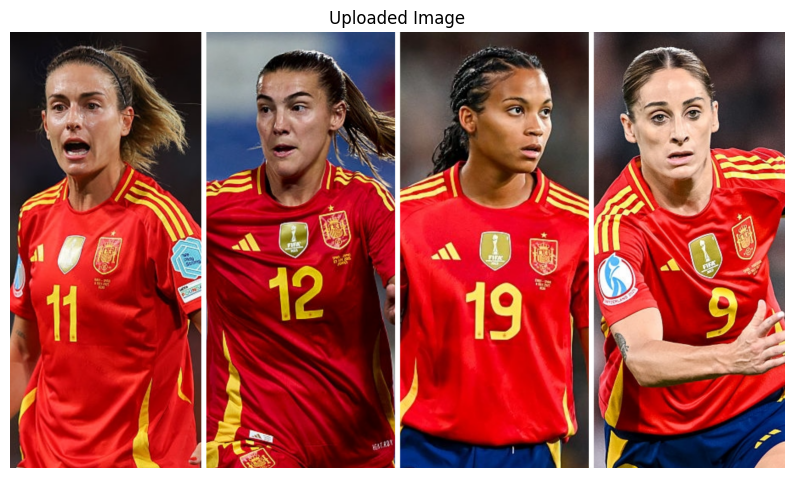

In [14]:
import os
import tempfile
import cv2 as cv
import numpy as np
import PIL.Image as Image
from google.colab import files
import matplotlib.pyplot as plt

# Variable for uploading files
image_path = ""
image_cv = None
image_pil = None
uploaded = files.upload()

for fn in uploaded.keys():
  print('- File "{name}" uploaded with length {length} bytes.'.format(
      name=fn, length=len(uploaded[fn])))

  # Save the uploaded file to a temporary location
  suffix = os.path.splitext(fn)[1] # Get extension
  with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp_file:
    tmp_file.write(uploaded[fn])
    image_path = tmp_file.name

  try:
    # Load the image using OpenCV
    image_cv = cv.imread(image_path)
    # Load as PIL image
    image_pil = Image.fromarray(cv.cvtColor(image_cv, cv.COLOR_BGR2RGB))
  except Exception as X:
    print(f"[Error]: Could not load image '{fn}' with OpenCV!")

  # Display the image
  if image_pil is not None:
    plt.figure(figsize=(10, 10))
    plt.imshow(image_pil)
    plt.title(f"Uploaded Image")
    plt.axis('off')
    plt.show()

## **II. Create and Initialize the 'KeyPoint RCNN' Model**

- First, you need to load a model checkpoint for keypoint detection:

In [32]:
from torchvision import models

# Create a model object from the "Keypoint RCNN" class
model = models.detection.keypointrcnn_resnet50_fpn(pretrained=True)

# Move the model to GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Call the eval() function to prepare the model
model.eval()

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=KeypointRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=KeypointRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


KeypointRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(640, 672, 704, 736, 768, 800), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.

- Now, we should define the required list of keypoints:

In [33]:
# Keypoints
keypoints = ['nose', 'left_eye', 'right_eye', 'left_ear', 'right_ear',
             'left_shoulder', 'right_shoulder','left_elbow', 'right_elbow',
             'left_wrist', 'right_wrist', 'left_hip', 'right_hip', 'left_knee',
             'right_knee', 'left_ankle', 'right_ankle']

# Define the Visualization Limbs
def getLimbsFromKeypoints(keypoints):
  limbs = [
      [keypoints.index('left_eye'), keypoints.index('nose')],
      [keypoints.index('right_eye'), keypoints.index('nose')],
      [keypoints.index('left_eye'), keypoints.index('left_ear')],
      [keypoints.index('left_hip'), keypoints.index('left_knee')],
      [keypoints.index('right_hip'), keypoints.index('left_hip')],
      [keypoints.index('right_eye'), keypoints.index('right_ear')],
      [keypoints.index('right_hip'), keypoints.index('right_knee')],
      [keypoints.index('left_knee'), keypoints.index('left_ankle')],
      [keypoints.index('left_elbow'), keypoints.index('left_wrist')],
      [keypoints.index('right_knee'), keypoints.index('right_ankle')],
      [keypoints.index('left_shoulder'), keypoints.index('left_hip')],
      [keypoints.index('right_elbow'), keypoints.index('right_wrist')],
      [keypoints.index('left_shoulder'), keypoints.index('left_elbow')],
      [keypoints.index('right_shoulder'), keypoints.index('right_hip')],
      [keypoints.index('right_shoulder'), keypoints.index('right_elbow')],
      [keypoints.index('right_shoulder'), keypoints.index('left_shoulder')]
      ]
  return limbs

# Limbs Values
limbs = getLimbsFromKeypoints(keypoints)

## **III. Pass the Image to the Model**

In [35]:
from torchvision import transforms as T

# Pre-process the Input Image
transform = T.Compose([T.ToTensor()])
img_tensor = transform(image_cv).to(device)

# Forward-Pass the Model
output = model([img_tensor])[0]

# Check the Output
print("- Model Output: ", output.keys())

- Model Output:  dict_keys(['boxes', 'labels', 'scores', 'keypoints', 'keypoints_scores'])


- Now, show the KeyPoints and skeletons on the Image:

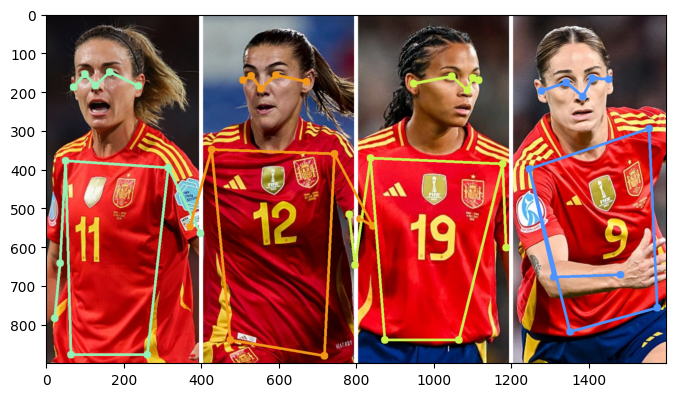

In [38]:
# Define a Function to Draw Per-Person KeyPoints
def drawKeypointsPerPerson(img, all_keypoints, all_scores, confs,
                           keypoint_threshold = 2, conf_threshold = 0.9):
    # Initialize a set of colors (rainbow spectrum)
    cmap = plt.get_cmap('rainbow')
    # Create a copy of the image
    img_copy = img.copy()
    # Pick a set of N Color-IDs from the spectrum
    color_id = np.arange(1, 255, 255 // len(all_keypoints)).tolist()[::-1]
    # Iterate for every person detected
    for person_id in range(len(all_keypoints)):
      # Check the confidence score of the detected person
      if confs[person_id] > conf_threshold:
        # Grab the Keypoint Location
        keypoints = all_keypoints[person_id, ...]
        # Grab the keypoint Scores
        scores = all_scores[person_id, ...]
        # Iterate for every Score
        for kp in range(len(scores)):
            # check the confidence score of detected keypoint
            if scores[kp]>keypoint_threshold:
                # Convert the keypoint float-array to a python-list of intergers
                keypoint = tuple(map(int, keypoints[kp, :2].detach().cpu().numpy().tolist()))
                # Pick the color at the specific color-id
                color = tuple(np.asarray(cmap(color_id[person_id])[:-1])*255)
                # Draw a cirle over the keypoint location
                cv.circle(img_copy, keypoint, 10, color, -1)
    return img_copy

# Define a Function to Draw Skeletons
def drawSkeletonPerPerson(img, all_keypoints, all_scores, confs,
                          keypoint_threshold = 2, conf_threshold = 0.9):
    # Initialize a set of colors (rainbow spectrum)
    cmap = plt.get_cmap('rainbow')
    # Create a copy of the image
    img_copy = img.copy()
    # Check if the keypoints are detected
    if len(output["keypoints"]) > 0:
      # Pick a set of N Color-IDs from the spectrum
      colors = np.arange(1, 255, 255 // len(all_keypoints)).tolist()[::-1]
      # Iterate for every person detect ed
      for person_id in range(len(all_keypoints)):
          # Check the confidence score of the detected person
          if confs[person_id]>conf_threshold:
            # Grab the keypoint-locations for the detected person
            keypoints = all_keypoints[person_id, ...]
            # Iterate for every limb
            for limb_id in range(len(limbs)):
              # Pick the start-point of the limb
              limb_loc1 = keypoints[limbs[limb_id][0], :2].detach().cpu().numpy().astype(np.int32)
              # Pick the start-point of the limb
              limb_loc2 = keypoints[limbs[limb_id][1], :2].detach().cpu().numpy().astype(np.int32)
              # Consider limb-confidence score as the minimum keypoint score among the two keypoint scores
              limb_score = min(all_scores[person_id, limbs[limb_id][0]], all_scores[person_id, limbs[limb_id][1]])
              # Check if limb-score is greater than threshold
              if limb_score> keypoint_threshold:
                # Pick the color at a specific color-id
                color = tuple(np.asarray(cmap(colors[person_id])[:-1])*255)
                # Draw the line for the limb
                cv.line(img_copy, tuple(limb_loc1), tuple(limb_loc2), color, 5)
    return img_copy

# Keypoint Images
keypoints_img = drawKeypointsPerPerson(image_cv, output["keypoints"],
                                      output["keypoints_scores"],
                                      output["scores"],
                                      keypoint_threshold = 2)

# Skeleton Images
skeleton_img = drawSkeletonPerPerson(keypoints_img, output["keypoints"],
                                     output["keypoints_scores"],
                                     output["scores"],
                                     keypoint_threshold=2)

plt.figure(figsize=(8, 8))
plt.imshow(skeleton_img[:, :, ::-1])
plt.show()

## **IV. Test on Videos**

In [43]:
import torch
import cv2 as cv
import numpy as np
from base64 import b64encode
from IPython.display import HTML
from torchvision import transforms as T

def process_video_keypoints(input_video_path,
                            output_video_path='output_video.mp4'):
    # 1. Open Video Capture
    cap = cv.VideoCapture(input_video_path)
    if not cap.isOpened():
        raise ValueError(f"- Could not open video file: {input_video_path}")

    # Video properties
    width = int(cap.get(cv.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv.CAP_PROP_FRAME_HEIGHT))
    fps = int(cap.get(cv.CAP_PROP_FPS)) or 30

    # 2. Setup Video Writer (H.264 codec for HTML5 browser compatibility)
    fourcc = cv.VideoWriter_fourcc(*'mp4v')
    out = cv.VideoWriter(output_video_path, fourcc, fps, (width, height))

    transform = T.Compose([T.ToTensor()])

    # Put model in eval mode
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    model.eval()

    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break

        # Pre-process: BGR -> RGB -> Tensor
        frame_rgb = cv.cvtColor(frame, cv.COLOR_BGR2RGB)
        img_tensor = transform(frame_rgb).to(device)

        # Forward Pass
        with torch.no_grad():
            output = model([img_tensor])[0]

        # Draw Keypoints and Skeleton (Thresholds adjusted to standard 0.5/0.8 range)
        keypoints_img = drawKeypointsPerPerson(
            frame,
            output["keypoints"],
            output["keypoints_scores"],
            output["scores"],
            keypoint_threshold=0.5,
            conf_threshold=0.8
        )

        skeleton_img = drawSkeletonPerPerson(
            keypoints_img,
            output["keypoints"],
            output["keypoints_scores"],
            output["scores"],
            keypoint_threshold=0.5,
            conf_threshold=0.8
        )

        # Write processed frame to output file
        out.write(skeleton_img)
        frame_count += 1

    cap.release()
    out.release()
    print(f"- Finished processing {frame_count} frames.")

    # 3. Re-encode video using ffmpeg so HTML5 standard players in Colab can play it
    !ffmpeg -y -i {output_video_path} -vcodec libx264 output_playable.mp4 -loglevel quiet

    # 4. Display the video inside Colab
    mp4 = open(output_video_path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    display(HTML(f'''
        <video controls width="600">
            <source src="{data_url}" type="video/mp4">
        </video>
    '''))

try:
  url = 'https://cdn.pixabay.com/video/2022/07/05/123232-727221558_large.mp4'
  process_video_keypoints(url)
except Exception as err:
  print(f"- Error: {err}")

- Error: integer division or modulo by zero
